# Calderon's Problem PlayGround

## Direct problem - forward finite differences solver

In [1]:
# filename: codebase/fdm_forward_solver.py
import os
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

### Generate the data

In [2]:



# ---------------------------------------------------------------------
# NEW: 2-D Fourier basis (NumPy version) and parametric gamma builder
# ---------------------------------------------------------------------
def make_fourier2d_basis_numpy(k_list, Lx=1.0, Ly=1.0, include_cos=True, include_sin=True):
    """
    Build 2D Fourier basis functions φ_i(x,y) using NumPy.

    Each basis function takes (xx, yy) meshgrid arrays and returns an (N,N) array.

    Args
    ----
    k_list : list of (kx, ky) integer tuples
    Lx, Ly : domain lengths (defaults 1.0)
    include_cos, include_sin : which families to include

    Returns
    -------
    basis_fns : list of callables φ(xx,yy) -> (N,N) array
    """
    basis_fns = []
    two_pi = 2.0 * np.pi

    for (kx, ky) in k_list:
        if include_cos:
            def phi_cos(xx, yy, kx=kx, ky=ky, Lx=Lx, Ly=Ly):
                return np.cos(two_pi * (kx * xx / Lx + ky * yy / Ly))
            basis_fns.append(phi_cos)
        if include_sin:
            def phi_sin(xx, yy, kx=kx, ky=ky, Lx=Lx, Ly=Ly):
                return np.sin(two_pi * (kx * xx / Lx + ky * yy / Ly))
            basis_fns.append(phi_sin)

    return basis_fns


def _softplus_numpy(z):
    # numerically stable softplus in numpy
    # softplus(z) = log(1 + exp(z))
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0.0)


def build_parametric_gamma_on_grid(N, c, k_list,
                                   Lx=1.0, Ly=1.0,
                                   include_cos=True, include_sin=True,
                                   background=0.0,
                                   positivity='none',
                                   min_gamma=None, max_gamma=None):
    """
    Build gamma(x,y) on an N x N grid as sum_i c_i φ_i(x,y).

    Args
    ----
    N : int
        grid size
    c : array-like (M,)
        coefficients for basis functions
    k_list, Lx, Ly, include_cos, include_sin : basis config
    background : float
        constant offset added to gamma (e.g., 1.0 to center around 1)
    positivity : {'none','softplus','sigmoid_bounds'}
        how to map raw gamma to positive/bounded range
    min_gamma, max_gamma : floats
        used only for 'sigmoid_bounds' to map into [min_gamma, max_gamma]

    Returns
    -------
    gamma : (N,N) np.ndarray
    """
    x = np.linspace(0.0, 1.0, N)
    y = np.linspace(0.0, 1.0, N)
    xx, yy = np.meshgrid(x, y, indexing='xy')  # xx: columns are x, yy: rows are y

    basis_fns = make_fourier2d_basis_numpy(k_list, Lx=Lx, Ly=Ly,
                                           include_cos=include_cos, include_sin=include_sin)

    c = np.asarray(c, dtype=float).ravel()
    if len(c) != len(basis_fns):
        raise ValueError(f"Length of c ({len(c)}) must equal number of basis functions ({len(basis_fns)}).")

    gamma_raw = np.zeros((N, N), dtype=float) + background
    for ci, phi in zip(c, basis_fns):
        gamma_raw += ci * phi(xx, yy)

    if positivity == 'none':
        gamma = gamma_raw
    elif positivity == 'softplus':
        gamma = _softplus_numpy(gamma_raw) + 1e-8
    elif positivity == 'sigmoid_bounds':
        if min_gamma is None or max_gamma is None:
            raise ValueError("Provide min_gamma and max_gamma for 'sigmoid_bounds'.")
        sig = 1.0 / (1.0 + np.exp(-gamma_raw))
        gamma = sig * (max_gamma - min_gamma) + min_gamma
    else:
        raise ValueError("positivity must be one of {'none','softplus','sigmoid_bounds'}.")

    return gamma


class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE ∇·(γ ∇u) = 0 on [0,1]×[0,1]
    with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:           # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:           # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }

    def _assemble_system(self, gamma):
        """
        Assemble the sparse matrix A for Au=b using harmonic means at interfaces.
        gamma is (N,N) array of conductivities.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for interface conductivities
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1]      =  gamma_E / h2  # East
                A[p, p - 1]      =  gamma_W / h2  # West
                A[p, p + self.N] =  gamma_N / h2  # North
                A[p, p - self.N] =  gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solve for u given gamma and Dirichlet boundary values (dict idx->value).
        gamma : (N,N) ndarray
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Compute boundary normal current J = gamma * (du/dn) using second-order
        one-sided stencils on the boundary.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
        
        J = np.zeros(len(bnd_indices))
        
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
                
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
                
                # Gradients (second-order one-sided on boundary)
                if j == 0:      # Left
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else:
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                if i == 0:      # Bottom
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else:
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
                
        return J


# ---------------------------------------------------------------------
# Existing canned γ fields (kept for convenience / backwards-compat)
# ---------------------------------------------------------------------
def get_gamma_single_inclusion(N):
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.2
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask = (xx - center_x)**2 + (yy - center_y)**2 < radius**2
    gamma[mask] = 2.0
    return gamma

def get_gamma_gaussian(N):
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.1
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    sigma = radius
    gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
    gamma += gaussian
    return gamma

def get_gamma_radial_sine(N, freq=5, amplitude=1.0):
    gamma = np.ones((N, N))
    center_x, center_y = 0.5, 0.5
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    gamma += amplitude * np.sin(2 * np.pi * freq * r)
    return gamma

def get_gamma_multiple_inclusions(N):
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask1 = (xx - 0.3)**2 + (yy - 0.6)**2 < 0.15**2
    gamma[mask1] = 2.0
    mask2 = (xx - 0.7)**2 + (yy - 0.3)**2 < 0.2**2
    gamma[mask2] = 0.5
    return gamma

def get_gamma_checkerboard(N):
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    checker = (np.floor(xx * 4) + np.floor(yy * 4)) % 2
    gamma[checker == 1] = 2.0
    return gamma


# ---------------------------------------------------------------------
# UPDATED: generate_dtn_data now supports parametric gamma
# ---------------------------------------------------------------------
def generate_dtn_data(case_name,
                      N,
                      K,
                      gamma_true=None,
                      gamma_param=None,
                      saving_path=None):
    """
    Generates and saves the DtN map data.

    You can provide EITHER:
      - gamma_true : (N,N) array (legacy path), OR
      - gamma_param : dict specifying parametric gamma with keys:
            {
              'c': [c1, c2, ...],             # list/array of coeffs
              'k_list': [(kx,ky), ...],
              'Lx': 1.0, 'Ly': 1.0,
              'include_cos': True,
              'include_sin': True,
              'background': 1.0,              # optional, default 0.0
              'positivity': 'none'|'softplus'|'sigmoid_bounds',
              'min_gamma': 0.5, 'max_gamma': 2.5  # if using sigmoid_bounds
            }

    Returns
    -------
    filename, example_u, example_fk, example_Jk
    """
    print(f"--- Starting data generation for case: {case_name} ---")

    # ----- Build gamma on grid -----
    if gamma_true is None and gamma_param is None:
        raise ValueError("Provide either gamma_true (array) or gamma_param (dict).")

    if gamma_param is not None:
        c = gamma_param['c']
        k_list = gamma_param['k_list']
        Lx = gamma_param.get('Lx', 1.0)
        Ly = gamma_param.get('Ly', 1.0)
        include_cos = gamma_param.get('include_cos', True)
        include_sin = gamma_param.get('include_sin', True)
        background = gamma_param.get('background', 0.0)
        positivity = gamma_param.get('positivity', 'none')
        min_g = gamma_param.get('min_gamma', None)
        max_g = gamma_param.get('max_gamma', None)

        gamma_true = build_parametric_gamma_on_grid(
            N, c, k_list, Lx=Lx, Ly=Ly,
            include_cos=include_cos, include_sin=include_sin,
            background=background,
            positivity=positivity, min_gamma=min_g, max_gamma=max_g
        )
    else:
        # validate provided array
        if gamma_true.shape != (N, N):
            raise ValueError(f"gamma_true must be shape ({N},{N}). Got {gamma_true.shape}.")

    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info['indices']
    bnd_coords = bnd_info['coords']

    # Define K boundary conditions (kept as in your code; expand if needed)
    freq_pairs = [(1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 1), (1, 2), (2, 2),
                  (3, 0), (0, 3), (3, 1), (1, 3), (3, 2), (2, 3), (3, 3), (4, 0)]
    if K > 2 * len(freq_pairs):
        raise ValueError(f"K={K} exceeds available (2 × {len(freq_pairs)}) sin/cos boundary modes.")

    boundary_potentials = []
    clean_currents = []
    induced_potentials = []

    start_time = time.time()
    for k in range(K):
        m, n = freq_pairs[k // 2]
        is_sin = (k % 2 == 1)
        if is_sin:
            f_k = np.sin(m * np.pi * bnd_coords[:, 0] + n * np.pi * bnd_coords[:, 1])
        else:
            f_k = np.cos(m * np.pi * bnd_coords[:, 0] + n * np.pi * bnd_coords[:, 1])

        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}

        # Solve and compute J
        u_k = solver.solve(gamma_true, boundary_values)
        J_k = solver.compute_normal_current(u_k, gamma_true)

        boundary_potentials.append(f_k)
        clean_currents.append(J_k)
        induced_potentials.append(u_k)

        if (k + 1) % 8 == 0:
            print(f"Generated data for {k + 1}/{K} boundary conditions...")

    boundary_potentials = np.array(boundary_potentials)
    clean_currents = np.array(clean_currents)
    induced_potentials = np.array(induced_potentials)

    # ---- Save data ----
    if saving_path is None:
        data_folder = "data_pablo_trial"
    else:
        data_folder = saving_path
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)

    filename = os.path.join(data_folder, f"dtn_data_{case_name}.npz")
    np.savez_compressed(
        filename,
        gamma_true=gamma_true,
        boundary_coords=bnd_coords,
        boundary_potentials=boundary_potentials,
        clean_currents=clean_currents,
        induced_potentials=induced_potentials,
        grid_N=N,
        num_bcs=K
    )

    end_time = time.time()
    print(f"Data generation for {case_name} complete. Time elapsed: {round(end_time - start_time, 2)}s")
    print("Dataset saved to " + filename)

    # Stats
    print("\n--- Dataset Statistics (" + case_name + ") ---")
    print("FDM Grid Size:", f"{N}x{N}")
    print("Number of Boundary Functions (K):", K)
    print("Boundary Points per Function:", bnd_coords.shape[0])
    print("Min/Max of Boundary Potential (f_k):", round(np.min(boundary_potentials), 2), "/", round(np.max(boundary_potentials), 2))
    print("Mean of Clean Current Density (J_k):", round(np.mean(clean_currents), 4))
    print("Std. Dev. of Clean Current Density (J_k):", round(np.std(clean_currents), 2))
    print("Min/Max of Clean Current Density (J_k):", round(np.min(clean_currents), 2), "/", round(np.max(clean_currents), 2))

    # Return one example for plotting
    example_u = solver.solve(gamma_true, {idx: val for idx, val in zip(bnd_indices, boundary_potentials[0])})
    return filename, example_u, boundary_potentials[0], clean_currents[0]




In [ ]:

# ------------ ADD/REPLACE THIS "main" IN YOUR fdm_forward_solver.py ------------
def main(N, K, saving_path=None):
    """
    Generate datasets and summary plots.
    Works with both canned gamma fields and the new parametric Fourier gamma.
    """
    if saving_path is None:
        saving_path = "data"
    
    '''
    # ------------------------------
    # (A) Legacy canned gamma cases
    # ------------------------------
    cases_array = {
        # "single_inclusion": get_gamma_single_inclusion(N),
        # "gaussian_inclusion": get_gamma_gaussian(N),
        "radially_sym_sine": get_gamma_radial_sine(N),
        # "multiple_inclusions": get_gamma_multiple_inclusions(N),
        # "checkerboard": get_gamma_checkerboard(N),
    }

    for name, gamma_true in cases_array.items():
        # NOTE: new signature generate_dtn_data(case_name, N, K, gamma_true=None, gamma_param=None, saving_path=None)
        filepath, u_ex, f_ex, J_ex = generate_dtn_data(
            case_name=name,
            N=N,
            K=K,
            gamma_true=gamma_true,
            saving_path=saving_path
        )

        # ---- Plotting (same as before) ----
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Plot 1: Ground Truth Gamma
        im0 = axes[0].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
        axes[0].set_title("Ground Truth Conductivity (gamma)")
        axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
        fig.colorbar(im0, ax=axes[0], orientation='vertical')

        # Plot 2: Example Potential Solution u_k
        im1 = axes[1].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[1].set_title("Example Potential Field u_0(x,y)")
        axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
        fig.colorbar(im1, ax=axes[1], orientation='vertical')

        # Plot 3: Example DtN data pair (f_k, J_k)
        bnd_info = FDMForwardSolver(N).boundary_info
        bnd_coords = bnd_info['coords']
        perimeter = np.zeros(len(bnd_coords))
        for i in range(1, len(bnd_coords)):
            perimeter[i] = perimeter[i-1] + np.linalg.norm(bnd_coords[i] - bnd_coords[i-1])

        axes[2].plot(perimeter, f_ex, 'b-', label='Potential f_0')
        ax2_twin = axes[2].twinx()
        ax2_twin.plot(perimeter, J_ex, 'r-', label='Current J_0')
        axes[2].set_title("Example DtN Pair on Boundary")
        axes[2].set_xlabel("Perimeter along Boundary")
        axes[2].set_ylabel("Potential (V)", color='b')
        ax2_twin.set_ylabel("Current Density (A/m^2)", color='r')
        axes[2].grid(True)

        fig.tight_layout()
        plot_filename = os.path.join(saving_path, f"plot_summary_{name}_{int(time.time())}.png")
        plt.savefig(plot_filename, dpi=300)
        print("\nSummary plot saved to " + plot_filename)
        plt.close(fig)
        print("\n" + "="*50 + "\n")

        '''
    # -------------------------------------------------------------
    # (B) Parametric Fourier gamma (NEW) — uses your current builder
    # -------------------------------------------------------------
    # With k_list=[(1,0),(0,1),(1,1)] and include_cos=True/include_sin=True,
    # you get 6 basis functions in this order:
    #   [cos(1,0), sin(1,0), cos(0,1), sin(0,1), cos(1,1), sin(1,1)]
    # Provide 6 coefficients in the SAME order:
    gamma_param = {
        'k_list': [(1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 2), (1,2), (2,1)],
        'Lx': 1.0, 'Ly': 1.0,
        'include_cos': True,
        'include_sin': True,
        'c': [0.40, -0.20, 0.30, 0.15, 0.10, 0.40,0.9, 0.55, 1.25, 0.00, -0.87, -1.21, -0.98, 1.23, -0.50, 1.69], # 6 coeffs -> matches 6 basis functions
        'positivity ' : 'sigmoid_bounds',
        
        'background': 1.0,
        #'positivity': 'none',  # or 'softplus' / 'sigmoid_bounds' (+ min/max)
        'min_gamma': 0.5, 
        'max_gamma': 2.5,        # if you pick 'sigmoid_bounds'
    }

    # Build the gamma array we’ll plot in panel[0] below
    gamma_parametric = build_parametric_gamma_on_grid(
        N=N,
        c=gamma_param['c'],
        k_list=gamma_param['k_list'],
        Lx=gamma_param.get('Lx', 1.0),
        Ly=gamma_param.get('Ly', 1.0),
        include_cos=gamma_param.get('include_cos', True),
        include_sin=gamma_param.get('include_sin', True),
        background=gamma_param.get('background', 0.0),
        positivity=gamma_param.get('positivity', 'none'),
        min_gamma=gamma_param.get('min_gamma', None),
        max_gamma=gamma_param.get('max_gamma', None)
    )

    name = "fourier_parametric_16terms"
    filepath, u_ex, f_ex, J_ex = generate_dtn_data(
        case_name=name,
        N=N,
        K=K,
        gamma_param=gamma_param,
        saving_path=saving_path
    )

    # ---- Plotting for the parametric case ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Ground Truth Gamma (parametric)
    im0 = axes[0].imshow(gamma_parametric, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
    axes[0].set_title("Ground Truth Conductivity (gamma) — parametric Fourier")
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    fig.colorbar(im0, ax=axes[0], orientation='vertical')

    # Plot 2: Example Potential Solution u_k
    im1 = axes[1].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    axes[1].set_title("Example Potential Field u_0(x,y)")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    fig.colorbar(im1, ax=axes[1], orientation='vertical')

    # Plot 3: Example DtN pair (f_0, J_0) along boundary
    bnd_info = FDMForwardSolver(N).boundary_info
    bnd_coords = bnd_info['coords']
    perimeter = np.zeros(len(bnd_coords))
    for i in range(1, len(bnd_coords)):
        perimeter[i] = perimeter[i-1] + np.linalg.norm(bnd_coords[i] - bnd_coords[i-1])

    axes[2].plot(perimeter, f_ex, 'b-', label='Potential f_0')
    ax2_twin = axes[2].twinx()
    ax2_twin.plot(perimeter, J_ex, 'r-', label='Current J_0')
    axes[2].set_title("Example DtN Pair on Boundary (parametric γ)")
    axes[2].set_xlabel("Perimeter along Boundary")
    axes[2].set_ylabel("Potential (V)", color='b')
    ax2_twin.set_ylabel("Current Density (A/m^2)", color='r')
    axes[2].grid(True)

    fig.tight_layout()
    plot_filename = os.path.join(saving_path, f"plot_summary_{name}_{int(time.time())}.png")
    plt.savefig(plot_filename, dpi=300)
    print("\nSummary plot saved to " + plot_filename)
    plt.close(fig)
    print("\n" + "="*50 + "\n")


# # Convenience CLI
# if __name__ == "__main__":
#     # Example usage: generate 64×64 data with K=32 boundary functions
#     main(N=64, K=32, saving_path="data_pablo_trial")



## 16 fourier terms, not the below
$\gamma(x, y) = 1 + 0.4\cos(2\pi x) - 0.2\sin(2\pi x) + 0.3\cos(2\pi y) + 0.15\sin(2\pi y) + 0.1\cos(2\pi(x + y))$


In [4]:
N=32
K=32
saving_path="Ali_NEW_APPROACH_TRIAL_2"


In [5]:
main(N=N, K=K, saving_path=saving_path)

--- Starting data generation for case: fourier_parametric_16terms ---


c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Generated data for 8/32 boundary conditions...
Generated data for 16/32 boundary conditions...
Generated data for 24/32 boundary conditions...
Generated data for 32/32 boundary conditions...
Data generation for fourier_parametric_16terms complete. Time elapsed: 60.93s
Dataset saved to Ali_NEW_APPROACH_TRIAL_2\dtn_data_fourier_parametric_16terms.npz

--- Dataset Statistics (fourier_parametric_16terms) ---
FDM Grid Size: 32x32
Number of Boundary Functions (K): 32
Boundary Points per Function: 124
Min/Max of Boundary Potential (f_k): -1.0 / 1.0
Mean of Clean Current Density (J_k): -1.1667
Std. Dev. of Clean Current Density (J_k): 22.59
Min/Max of Clean Current Density (J_k): -187.83 / 117.34

Summary plot saved to Ali_NEW_APPROACH_TRIAL_2\plot_summary_fourier_parametric_16terms_1761230524.png




### Analysis

In [6]:
# Load the compressed npz file
# data = np.load(f"data_pablo_trial/dtn_data_single_inclusion.npz")

data = np.load(f"{saving_path}/dtn_data_fourier_parametric_16terms.npz")

# See what keys are inside
print("Keys in file:")
for key in data.keys():
    print(key)

Keys in file:
gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs


In [7]:
gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords = data["boundary_coords"]     # (num_boundary_points, 2)
u_all = data["induced_potentials"]      # (K, N, N)
f_all = data["boundary_potentials"]      # (K, num_boundary_points)
J_all = data["clean_currents"]           # (K, num_boundary_points)
# J_noisy1 = data["noisy_currents_1pct"]   # same shape, noisy
# J_noisy5 = data["noisy_currents_5pct"]   # same shape, noisy
N = int(data["grid_N"])
K = int(data["num_bcs"])


In [8]:
f_all.shape

(32, 124)

(32, 32)


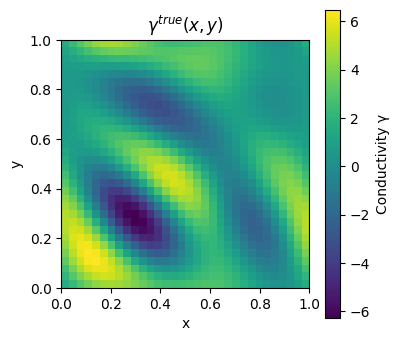

In [9]:
print(gamma_true.shape)


fig = plt.figure(figsize=(4,4))
plt.imshow(gamma_true, origin='lower', extent=[0,1,0,1], cmap="viridis")
plt.colorbar(label="Conductivity γ")
plt.title(r"$\gamma^{true}(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [10]:
f_all.shape

(32, 124)

u_all shape (32, 32, 32)


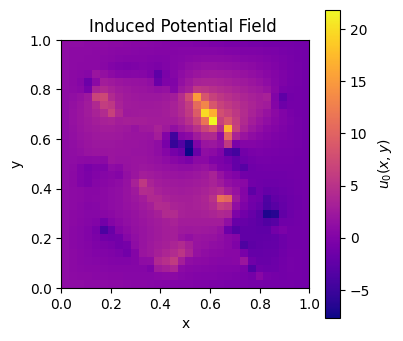

In [11]:
k=0

print('u_all shape', u_all.shape)

u_ex = u_all[k,:,:]

fig = plt.figure(figsize=(4,4))
im1 = plt.imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
plt.title(r"Induced Potential Field ")
plt.xlabel("x")
plt.ylabel("y")
fig.colorbar(im1, label=r'$u_0(x,y)$', orientation='vertical')
plt.show()

(0.0, 127.0)

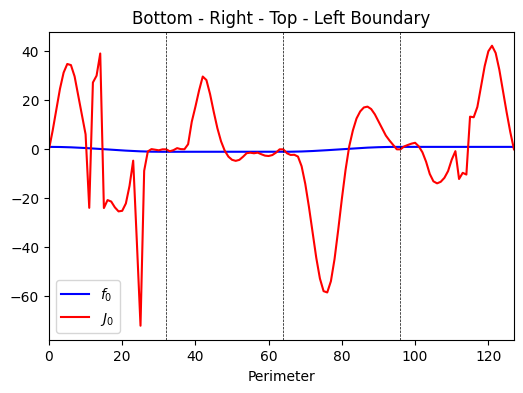

In [12]:
k = 0

######### CHAT GPT ################

x, y = bnd_coords[:,0], bnd_coords[:,1]

# Identify edges
tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# Sort along each edge
bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# Concatenate perimeter
perimeter_idx = np.concatenate([bottom_idx, right_idx, top_idx, left_idx])

# Reorder f and J consistently
f_true = f_all[k, perimeter_idx]
J_true = J_all[k, perimeter_idx]

afine = np.arange(4*(N))


#################

fig = plt.figure(figsize=(6,4))
plt.plot(afine, f_true, 'b-', label=r"$f_0$")
plt.plot(afine, J_true, 'r-', label=r"$J_0$")
for i in range(1,4):
    plt.axvline(i*N, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Perimeter')
plt.legend()
plt.title('Bottom - Right - Top - Left Boundary')

plt.xlim(left=0, right = 4*N-1)


# fig = plt.figure(figsize=(10,2))
# plt.scatter(left_true[:,1], f_left, color='b', s=20)
# plt.scatter(right_true[:-2,1], f_right[:-2], color='r', s=5)
# # plt.scatter(right_true[-1,1], f_right[-1], color='g', s=5)
# plt.show()

# fig = plt.figure(figsize=(4,4))
# plt.scatter(bottom[:,0], f_bottom, color='g', s=5)
# plt.scatter(top[:,0], f_top, color='m', s=5)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


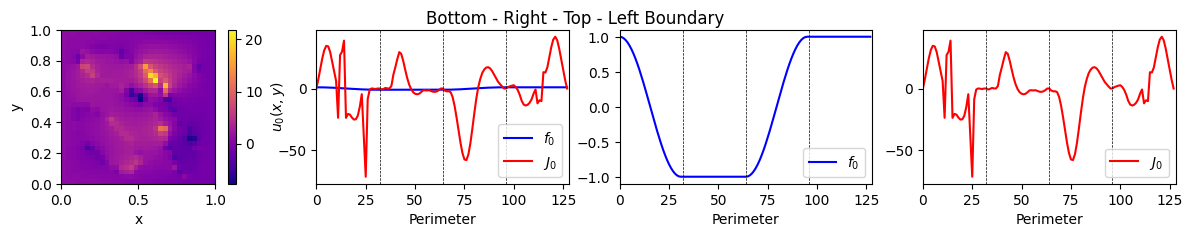

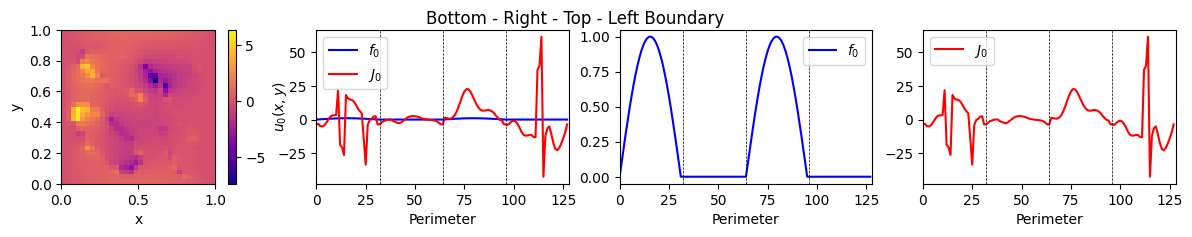

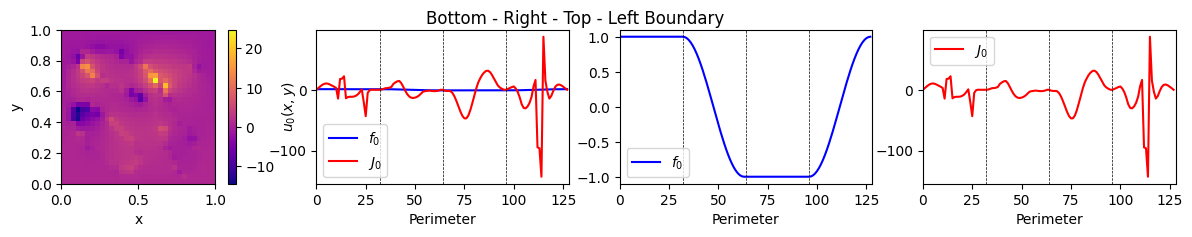

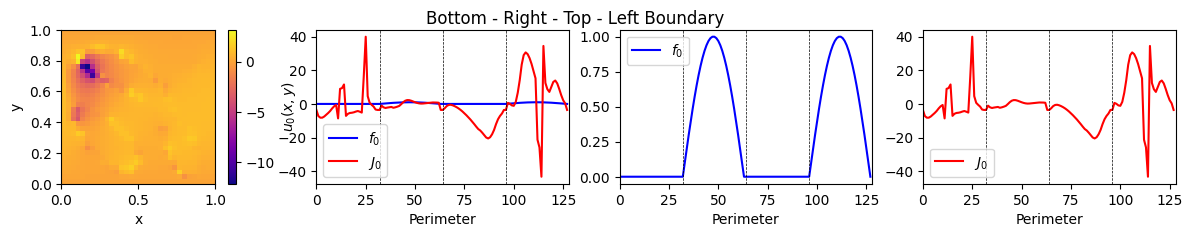

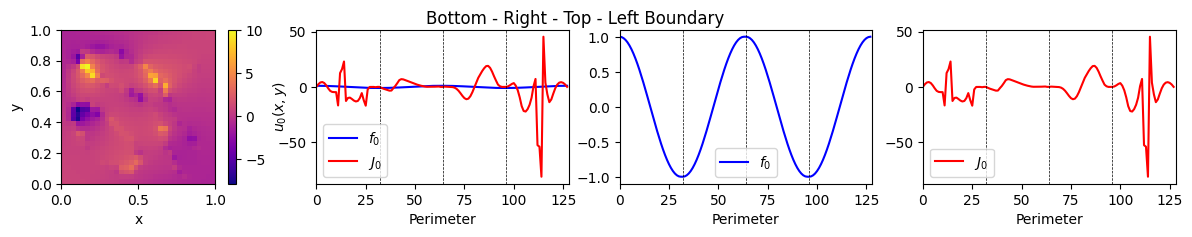

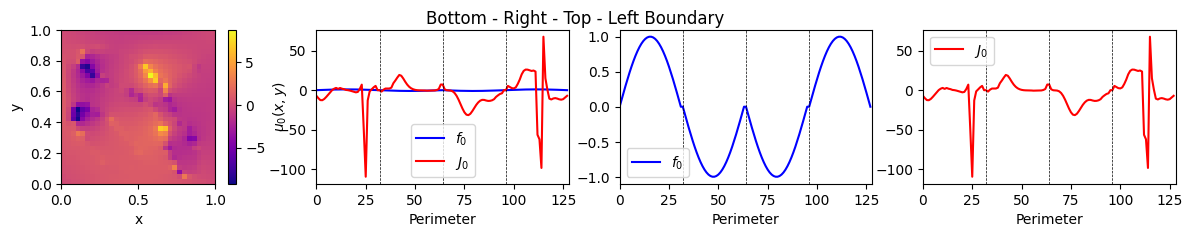

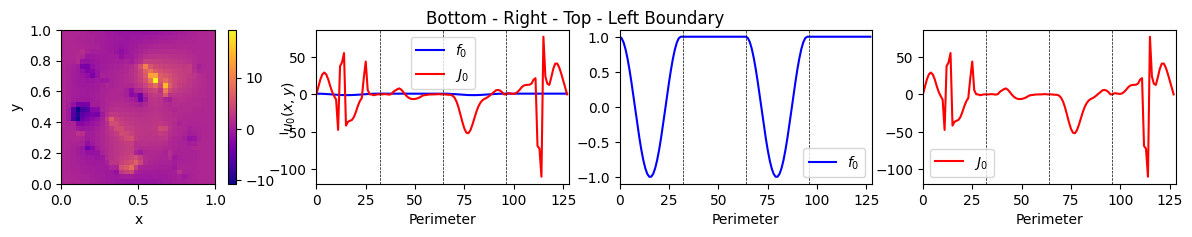

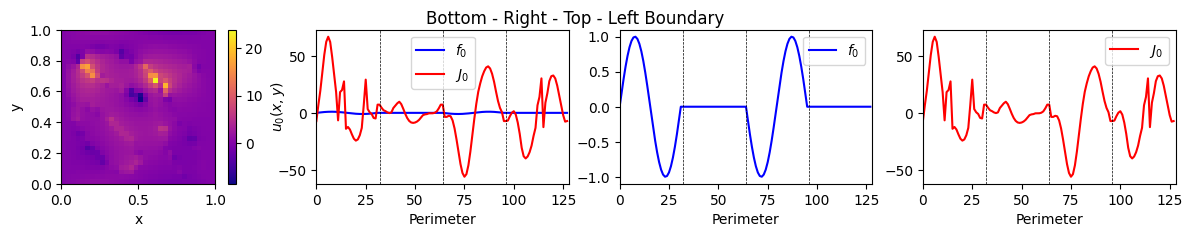

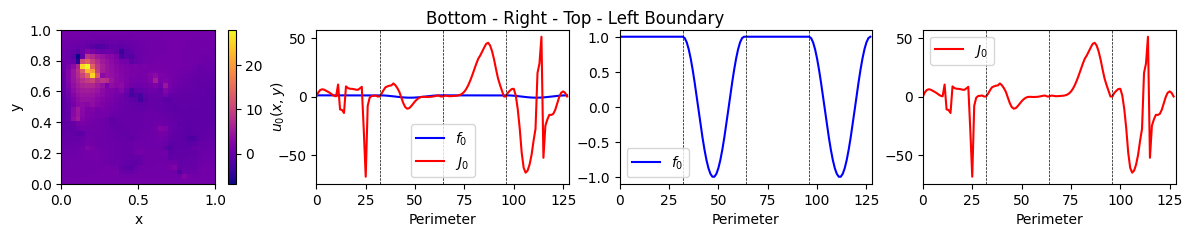

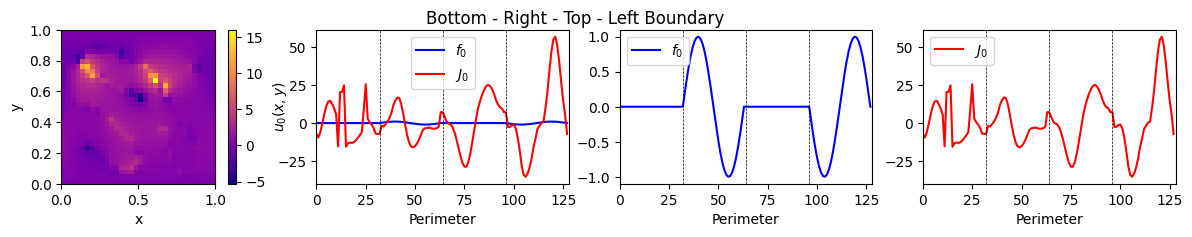

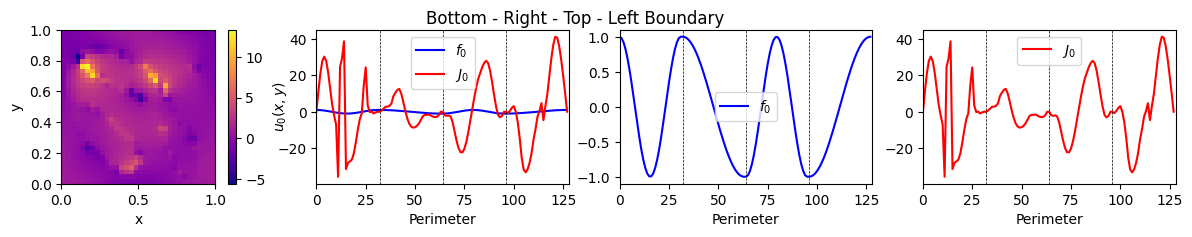

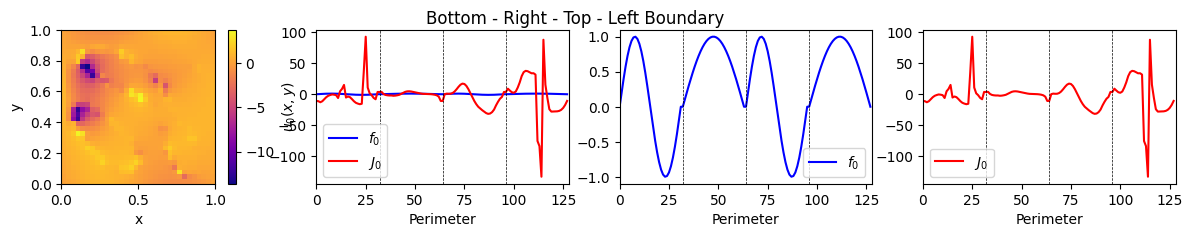

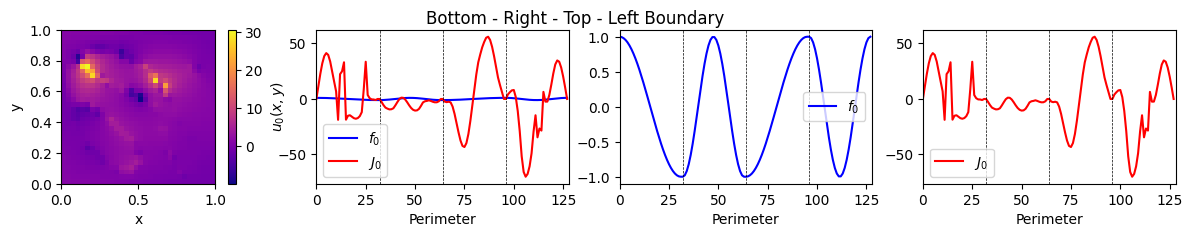

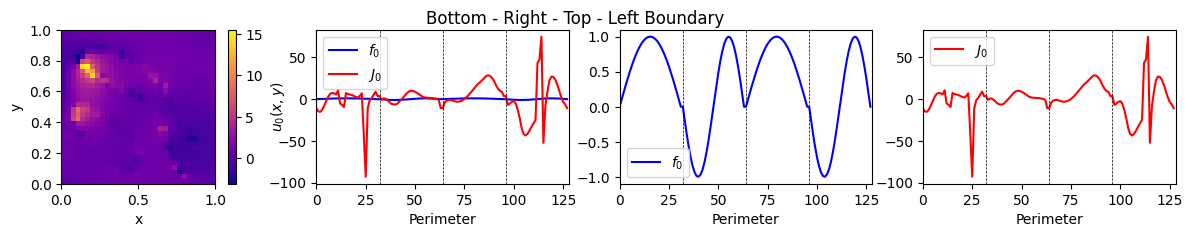

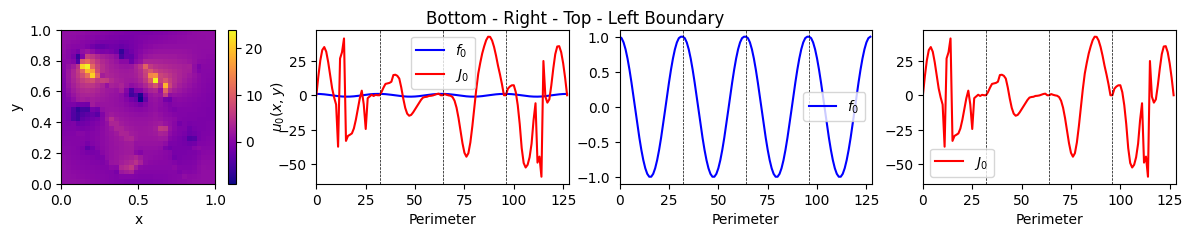

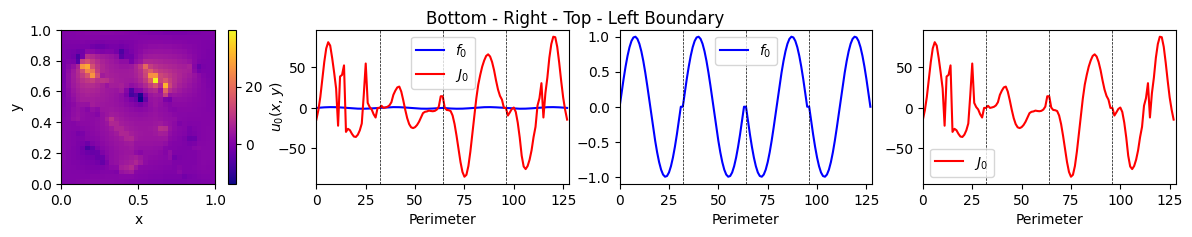

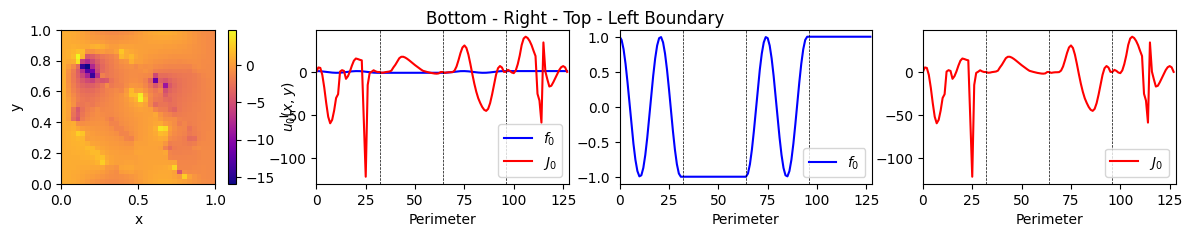

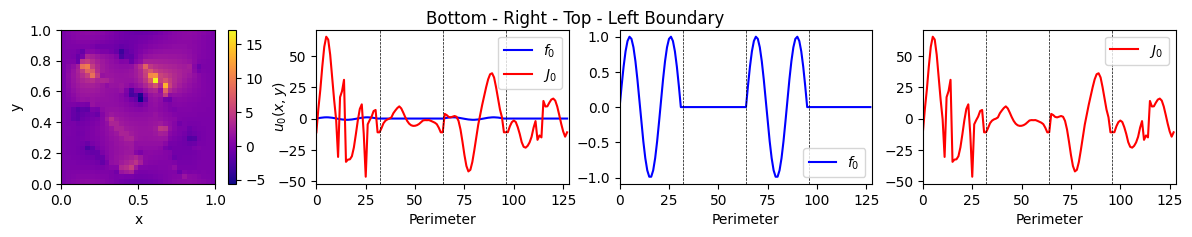

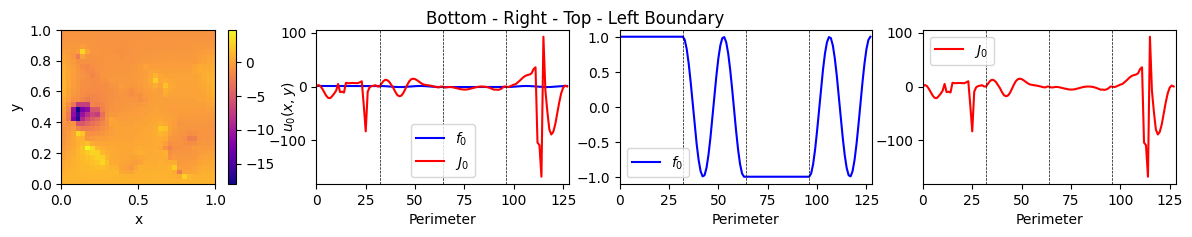

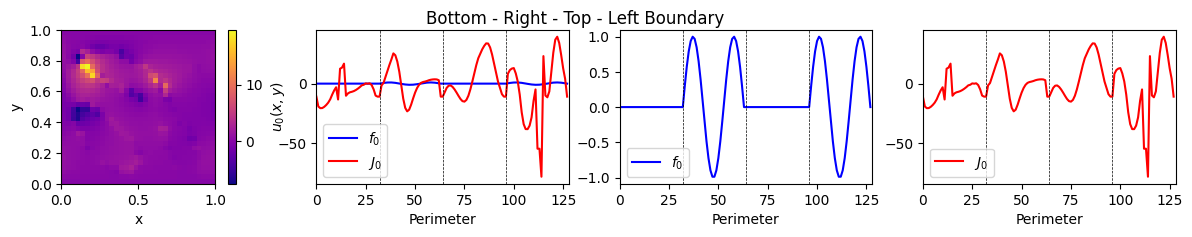

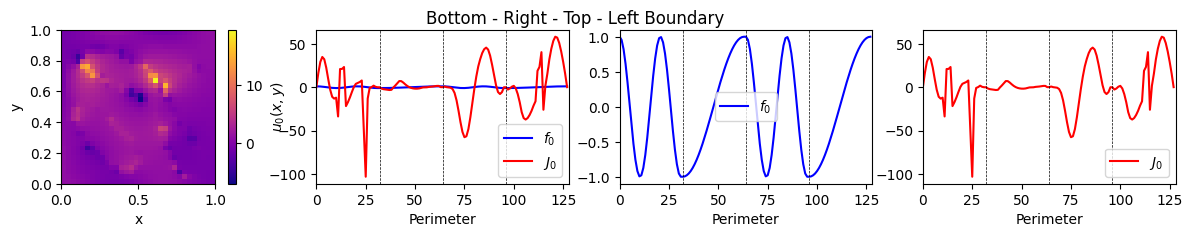

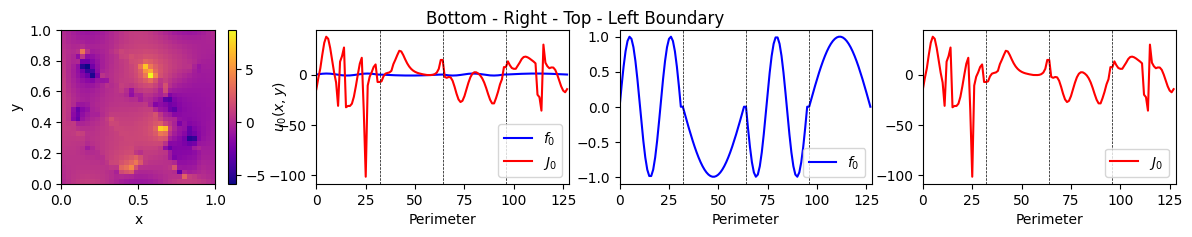

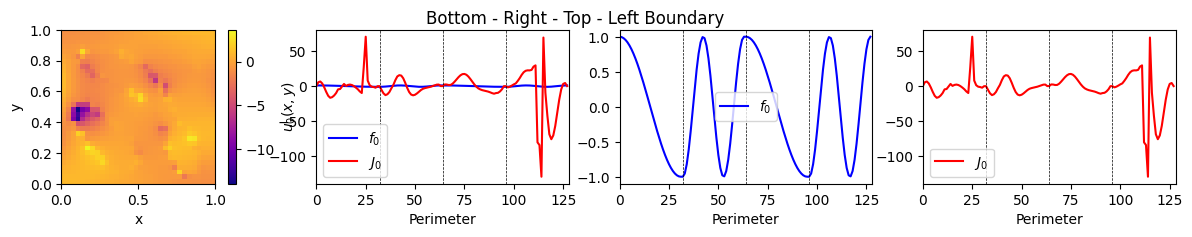

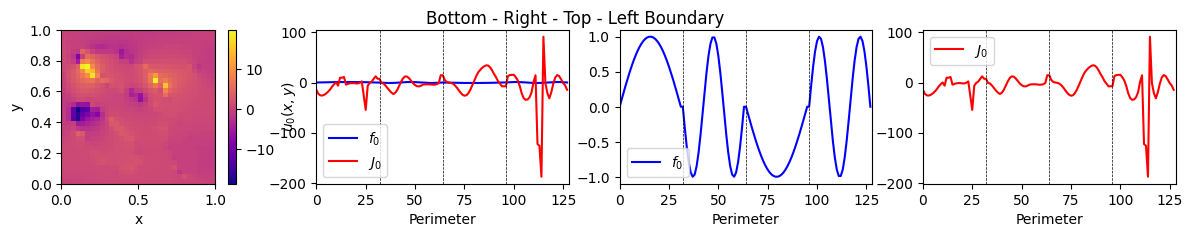

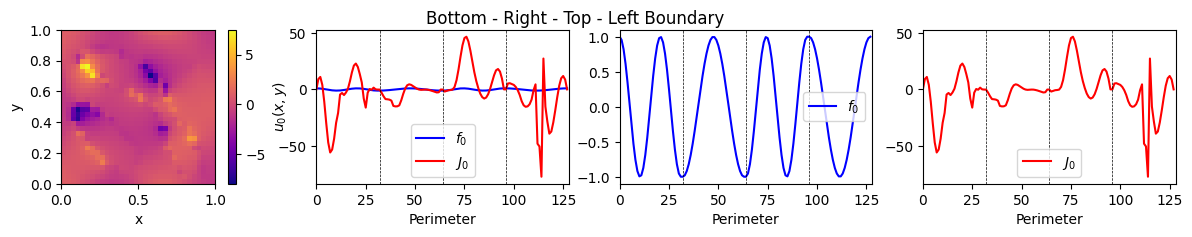

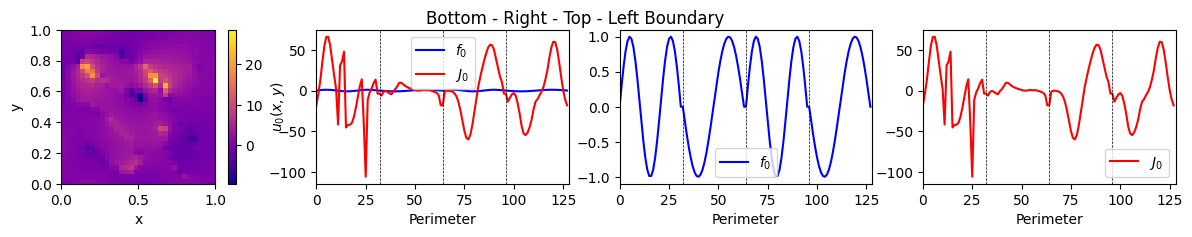

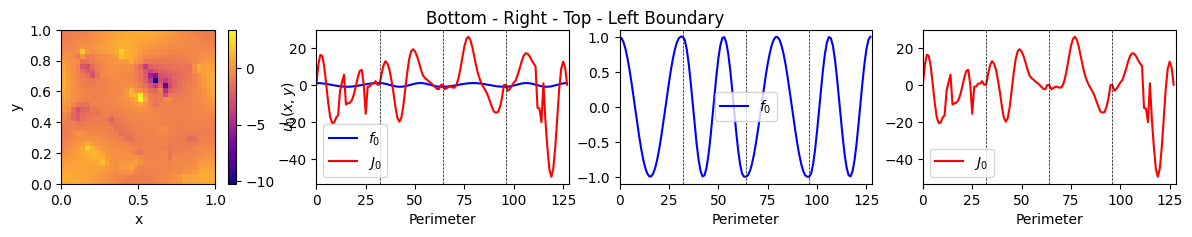

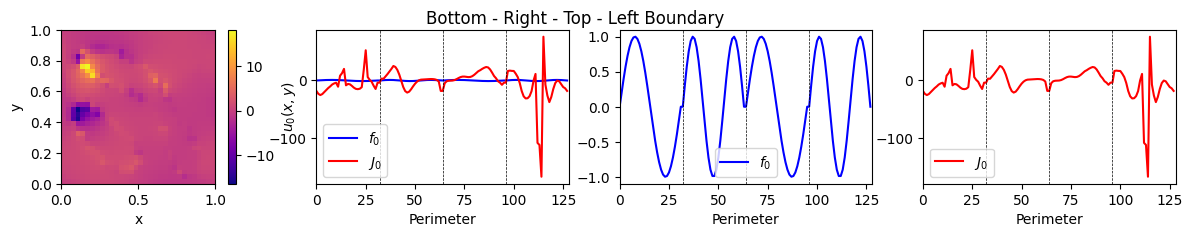

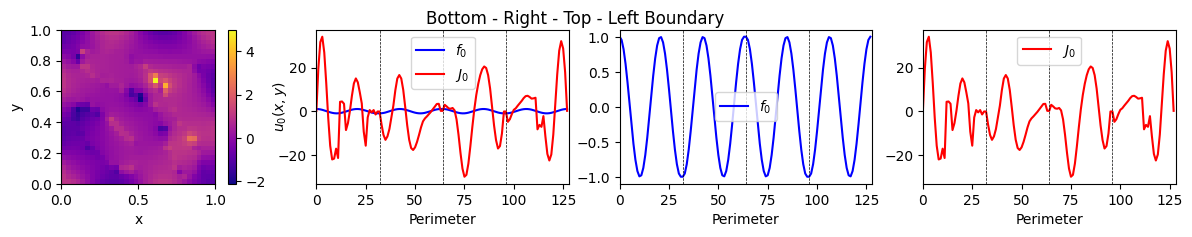

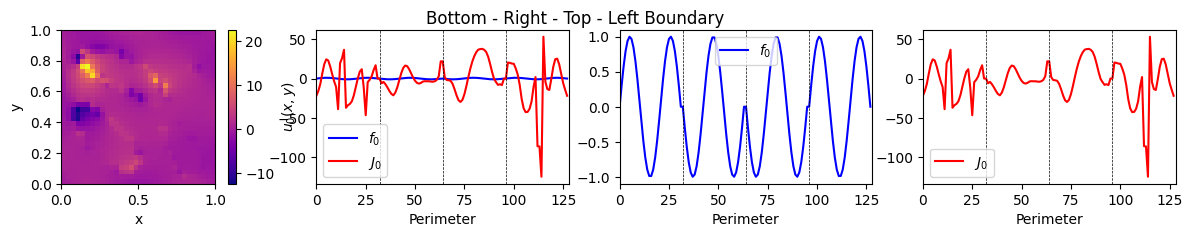

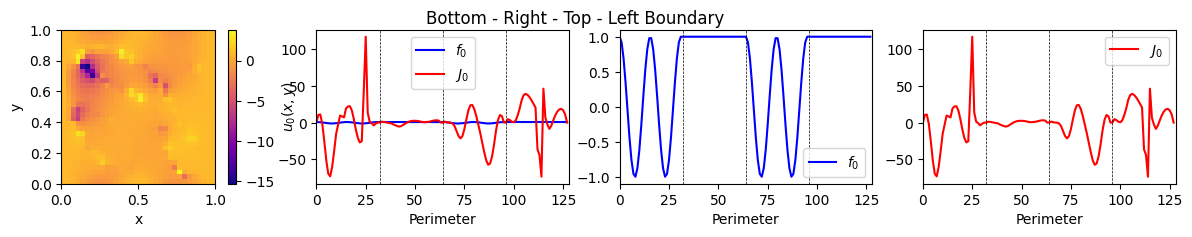

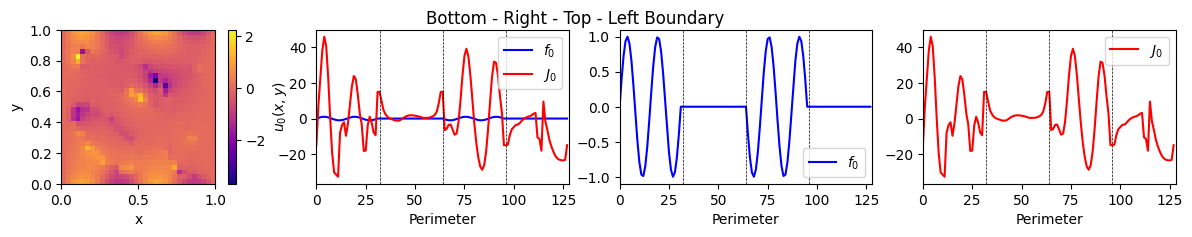

In [13]:
k_list=np.arange(K)
print(k_list)

for k in (k_list):

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]

    fig,ax = plt.subplots(1,4,figsize=(15,2))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)

    ax[3].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[3].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4*N)
    
    plt.suptitle('Bottom - Right - Top - Left Boundary')

    plt.show()
